In [232]:
import pandas as pd
import numpy as np
import json
import os
from datetime import datetime, timedelta
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import joblib
import sys
import matplotlib.pyplot as plt
import seaborn as sns
import time 

In [233]:
# ACCESS_REQUESTS_FILE = os.path.join(os.path.dirname(os.getcwd()), 'access_requests.json')
ACCESS_REQUESTS_FILE = os.path.join(os.getcwd(), 'training_requests.json')
MODEL_SAVE_PATH         = os.path.join(os.getcwd(), 'isolation_forest_model.joblib')
PREPROCESSOR_SAVE_PATH  = os.path.join(os.path.dirname(os.getcwd()), 'iforest_preprocessor.joblib')
FEATURE_NAMES_SAVE_PATH = os.path.join(os.getcwd(), 'iforest_feature_names.json')
POLICY_CONFIG_FILE = os.path.join(os.path.dirname(os.getcwd()), 'policyConfiguration.yml')

In [234]:
def load_data(filepath):
    """Loads access request data from JSON file."""
    print(f"Loading data from: {filepath}")
    try:
        df = pd.read_json(filepath, orient='records')
        print(f"Loaded {len(df)} records.")
        # Convert timestamp immediately
        df['access_request_time'] = pd.to_datetime(df['access_request_time'])
        # Ensure ID is treated as an object/string if needed later, though not used as feature here
        if 'ID' in df.columns:
             df['ID'] = df['ID'].astype(str)
        return df
    except FileNotFoundError:
        print(f"Error: File not found at {filepath}")
        sys.exit(1)
    except Exception as e:
        print(f"Error loading data: {e}")
        sys.exit(1)

In [235]:

def engineer_features(df):
    """Engineers features for anomaly detection."""
    print("Starting feature engineering...")
    df = df.copy() # Avoid modifying the original DataFrame

    # Handle potential missing values before processing
    df['location'] = df['location'].fillna('Unknown/Unknown')
    df['device_OS'] = df['device_OS'].fillna('Unknown')
    df['device_type'] = df['device_type'].fillna('Unknown')
    df['resource_requested'] = df['resource_requested'].fillna('Unknown')

    # 1. Temporal Features
    df['hour'] = df['access_request_time'].dt.hour
    df['day_of_week'] = df['access_request_time'].dt.dayofweek # Monday=0, Sunday=6

    # Cyclical encoding for hour and day
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    df['day_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
    df['day_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

    # Time since last request (per user)
    df.sort_values(by=['user_id', 'access_request_time'], inplace=True)
    df['time_since_last_req_sec'] = df.groupby('user_id')['access_request_time'].diff().dt.total_seconds()
    # Fill NaN for the first request of each user (or if only one request exists)
    df['time_since_last_req_sec'] = df['time_since_last_req_sec'].fillna(0)

    # 2. Contextual Features (will be handled by OneHotEncoder)
    # Extract country code for location
    df['country'] = df['location'].apply(lambda x: x.split('/')[-1] if isinstance(x, str) and '/' in x else 'Unknown')

    # 3. Frequency Features (Per User) - More complex, calculating rolling counts
    print("Calculating frequency features (this might take a moment)...")
    df.sort_values(by='access_request_time', inplace=True) # Sort by time for rolling calculations

    # --- Rolling Requests per Hour (Lookback 1 hour) ---
    requests_per_hour = df.groupby('user_id').rolling('1h', on='access_request_time').count()['ID'] # Use 'ID' or any non-null column for counting
    # Correctly align the index after rolling
    requests_per_hour.index = requests_per_hour.index.droplevel(0) # Remove the user_id multi-index level temporarily for alignment
    df = df.join(requests_per_hour.rename('requests_last_1h'))
    df['requests_last_1h'] = df['requests_last_1h'].fillna(0)
    # Subtract 1 because rolling includes the current row
    df['requests_last_1h'] = (df['requests_last_1h'] - 1).clip(lower=0)


    # --- Rolling Requests per Day (Lookback 24 hours) ---
    requests_per_day = df.groupby('user_id').rolling('24h', on='access_request_time').count()['ID']
    requests_per_day.index = requests_per_day.index.droplevel(0)
    df = df.join(requests_per_day.rename('requests_last_24h'))
    df['requests_last_24h'] = df['requests_last_24h'].fillna(0)
     # Subtract 1 because rolling includes the current row
    df['requests_last_24h'] = (df['requests_last_24h'] - 1).clip(lower=0)

    print("Frequency features calculated.")

    # Select final features (excluding intermediate ones like 'hour', 'day_of_week')
    # Define numerical and categorical features AFTER creation
    numerical_features = ['hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'time_since_last_req_sec', 'requests_last_1h', 'requests_last_24h']
    categorical_features = ['resource_requested', 'country', 'device_OS', 'device_type']

    # Keep only selected features and user_id/time if needed for debugging/analysis
    # For training, we only need the feature columns
    feature_columns = numerical_features + categorical_features
    df_final = df[feature_columns].copy()

    print("Feature engineering completed.")
    print("Selected features:", feature_columns)
    print("Sample of engineered data:\n", df_final.head())

    return df_final, numerical_features, categorical_features

In [236]:
def train_model(X, numerical_features, categorical_features):
    """Trains the Isolation Forest model with preprocessing."""
    print("Starting model training...")

    # Create preprocessing pipelines for numerical and categorical features
    numerical_transformer = StandardScaler()
    categorical_transformer = OneHotEncoder(handle_unknown='ignore') # Ignore unknown categories during prediction

    # Create a column transformer to apply different transformations
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numerical_transformer, numerical_features),
            ('cat', categorical_transformer, categorical_features)
        ],
        remainder='passthrough' # Keep other columns if any (shouldn't be if X only contains feature cols)
    )

    # Define the Isolation Forest model
    # Contamination 'auto' is roughly 10%, adjust if needed, e.g., 0.01 for 1%
    model = IsolationForest(n_estimators=150,      # Increased estimators slightly
                            max_samples='auto',
                            contamination='auto', # Let the model estimate, or set explicitly (e.g., 0.05 for 5%)
                            random_state=42,
                            n_jobs=-1)            # Use all available CPU cores

    # Create the full pipeline: preprocess -> model
    pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('isolationforest', model)])

    # Fit the pipeline on the data (X should be the DataFrame with features)
    pipeline.fit(X)
    print("Model training completed.")

    # Extract feature names after one-hot encoding
    feature_names_out = pipeline.named_steps['preprocessor'].get_feature_names_out()
    print(f"Total features after preprocessing: {len(feature_names_out)}")


    # Save the entire pipeline (includes preprocessor and model)
    joblib.dump(pipeline, MODEL_SAVE_PATH)
    print(f"Trained pipeline saved to: {MODEL_SAVE_PATH}")

    # Save the feature names for consistency during prediction
    with open(FEATURE_NAMES_SAVE_PATH, 'w') as f:
        json.dump(feature_names_out.tolist(), f)
    print(f"Feature names saved to: {FEATURE_NAMES_SAVE_PATH}")

    # Optional: Save just the preprocessor if needed separately (though pipeline is better)
    # joblib.dump(preprocessor, PREPROCESSOR_SAVE_PATH)
    # print(f"Preprocessor saved to: {PREPROCESSOR_SAVE_PATH}")

    return pipeline, feature_names_out



In [237]:
raw_df = load_data(ACCESS_REQUESTS_FILE)

# 2. Engineer Features
features_df, num_cols, cat_cols = engineer_features(raw_df)


Loading data from: /home/bento/projects/ZTA/ZeroTrustArchitecture/Anomaly_model/training_requests.json
Loaded 1000 records.
Starting feature engineering...
Calculating frequency features (this might take a moment)...
Frequency features calculated.
Feature engineering completed.
Selected features: ['hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'time_since_last_req_sec', 'requests_last_1h', 'requests_last_24h', 'resource_requested', 'country', 'device_OS', 'device_type']
Sample of engineered data:
      hour_sin      hour_cos   day_sin  day_cos  time_since_last_req_sec  \
203  1.000000  6.123234e-17  0.781831  0.62349                      0.0   
625  1.000000  6.123234e-17  0.781831  0.62349                   2137.0   
897  0.965926 -2.588190e-01  0.781831  0.62349                      0.0   
241  0.965926 -2.588190e-01  0.781831  0.62349                   2609.0   
220  0.965926 -2.588190e-01  0.781831  0.62349                      0.0   

     requests_last_1h  requests_last_24h resour

In [238]:
if features_df.isnull().sum().any():
        print("\nWarning: NaN values found after feature engineering:")
        print(features_df.isnull().sum())
        print("Attempting to fill NaNs with 0 for numerical and 'Unknown' for categorical before training.")
        # Impute NaNs - Simple strategy (you might need more sophisticated imputation)
        for col in num_cols:
             if features_df[col].isnull().any():
                  features_df[col].fillna(0, inplace=True)
        for col in cat_cols:
             if features_df[col].isnull().any():
                  features_df[col].fillna('Unknown', inplace=True)
        # Double check
        if features_df.isnull().sum().any():
             print("Error: NaNs still present after attempting imputation. Exiting.")
             sys.exit(1)
        else:
             print("NaNs handled.")

In [239]:
trained_pipeline, final_feature_names = train_model(features_df, num_cols, cat_cols)

Starting model training...
Model training completed.
Total features after preprocessing: 27
Trained pipeline saved to: /home/bento/projects/ZTA/ZeroTrustArchitecture/Anomaly_model/isolation_forest_model.joblib
Feature names saved to: /home/bento/projects/ZTA/ZeroTrustArchitecture/Anomaly_model/iforest_feature_names.json


In [240]:
anomaly_scores = trained_pipeline.decision_function(features_df)

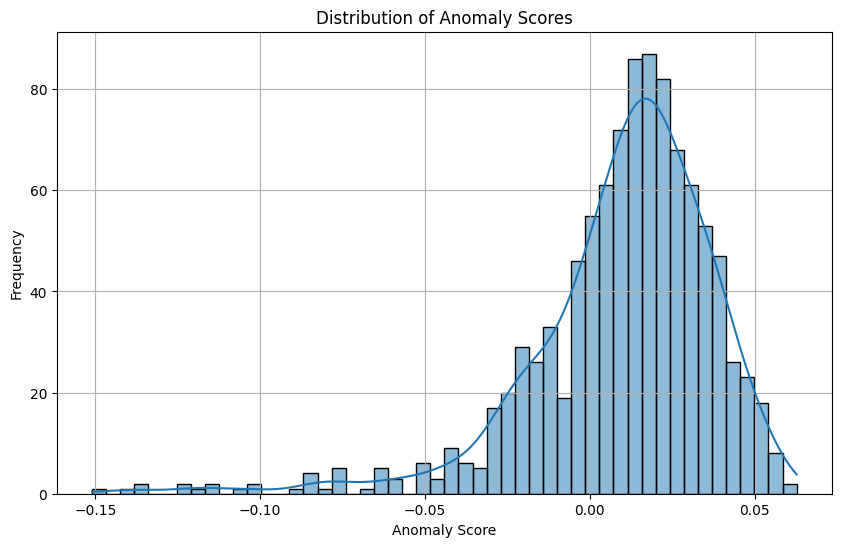

Number of anomalies detected (score < -0.02): 117
Percentage of anomalies: 11.70%


In [241]:

plt.figure(figsize=(10, 6))
sns.histplot(anomaly_scores, bins=50, kde=True)
plt.title('Distribution of Anomaly Scores')
plt.xlabel('Anomaly Score')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# You can also define a threshold and see how many are considered anomalies
# For Isolation Forest, scores are typically <= 0 for anomalies, with more negative being more anomalous.
# A common threshold is 0, but this depends on the 'contamination' parameter and desired sensitivity.
threshold = -0.02 # Example threshold
anomalies = anomaly_scores[anomaly_scores < threshold]
print(f"Number of anomalies detected (score < {threshold}): {len(anomalies)}")
print(f"Percentage of anomalies: {len(anomalies) / len(anomaly_scores) * 100:.2f}%")

In [242]:
_access_requests_df_cache = None
_access_requests_mtime = 0

def load_historical_access_requests():
    """Loads historical access requests, using a simple cache based on file modification time."""
    global _access_requests_df_cache, _access_requests_mtime
    try:
        current_mtime = os.path.getmtime(ACCESS_REQUESTS_FILE)
        if _access_requests_df_cache is None or current_mtime > _access_requests_mtime:
            print("(Re)Loading historical access requests for anomaly features...")
            df = pd.read_json(ACCESS_REQUESTS_FILE, orient='records')
            df['access_request_time'] = pd.to_datetime(df['access_request_time'])
            _access_requests_df_cache = df.sort_values(by='access_request_time') # Sort once
            _access_requests_mtime = current_mtime
            print("Historical data loaded.")
        return _access_requests_df_cache.copy() # Return a copy to prevent modification
    except FileNotFoundError:
        print(f"Error: Historical access requests file not found at {ACCESS_REQUESTS_FILE}")
        return pd.DataFrame() # Return empty DataFrame
    except Exception as e:
        print(f"Error loading historical access requests: {e}")
        return pd.DataFrame()

In [243]:
results_df = features_df.copy() 
results_df['anomaly_score'] = anomaly_scores
results_df['is_anomaly'] = results_df['anomaly_score'] < threshold
top_anomalies = results_df[results_df['is_anomaly']].sort_values(by='anomaly_score')
print(f"Top 10 anomalies detected (sorted by anomaly score):\n{top_anomalies.head(100)}")


Top 10 anomalies detected (sorted by anomaly score):
     hour_sin      hour_cos   day_sin   day_cos  time_since_last_req_sec  \
842 -0.965926  2.588190e-01  0.974928 -0.222521                      0.0   
111 -0.965926  2.588190e-01  0.974928 -0.222521                    480.0   
980 -0.965926  2.588190e-01  0.974928 -0.222521                    180.0   
642 -0.965926  2.588190e-01  0.974928 -0.222521                    360.0   
784 -0.965926  2.588190e-01  0.974928 -0.222521                    660.0   
..        ...           ...       ...       ...                      ...   
533 -0.500000 -8.660254e-01  0.974928 -0.222521                   4992.0   
630 -0.866025  5.000000e-01 -0.433884 -0.900969                    628.0   
418  1.000000  6.123234e-17  0.433884 -0.900969                  28825.0   
239 -0.707107  7.071068e-01  0.974928 -0.222521                   3878.0   
626 -0.500000  8.660254e-01  0.000000  1.000000                  32589.0   

     requests_last_1h  requests_la

### Single request pred


In [244]:
def prepare_features_for_prediction(current_request_dict):
    """Prepares a feature DataFrame for a single incoming request."""
    print("Preparing features for current request...")
    # Convert single request dict to a DataFrame row
    df = pd.DataFrame([current_request_dict])
    df['access_request_time'] = pd.to_datetime(df['access_request_time'])

    # Handle potential missing values (MUST match training)
    df['location'] = df['location'].fillna('Unknown/Unknown')
    df['device_OS'] = df['device_OS'].fillna('Unknown')
    df['device_type'] = df['device_type'].fillna('Unknown')
    df['resource_requested'] = df['resource_requested'].fillna('Unknown')

    # --- Replicate Feature Engineering ---
    # 1. Temporal Features
    df['hour'] = df['access_request_time'].dt.hour
    df['day_of_week'] = df['access_request_time'].dt.dayofweek
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    df['day_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
    df['day_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

    # --- Load historical data for lookups ---
    historical_df = load_historical_access_requests()
    if historical_df.empty:
         print("Warning: Cannot calculate historical features due to missing data.")
         df['time_since_last_req_sec'] = 0
         df['requests_last_1h'] = 0
         df['requests_last_24h'] = 0
    else:
        user_id = df['user_id'].iloc[0]
        current_time = df['access_request_time'].iloc[0]

        # Filter historical data for the specific user AND time *before* current request
        user_history = historical_df[(historical_df['user_id'] == user_id) &
                                     (historical_df['access_request_time'] < current_time)].copy() # Explicit copy
        print(f"Found {len(user_history)} historical requests for user {user_id} before current time {current_time}.")
        # 2. Time Since Last Request
        if not user_history.empty:
            last_req_time = user_history['access_request_time'].iloc[-1] # Already sorted
            time_diff = current_time - last_req_time
            df['time_since_last_req_sec'] = time_diff.total_seconds()
        else:
            df['time_since_last_req_sec'] = 0 # First request for user

        # 3. Frequency Features (use user_history filtered further by time window)
        one_hour_ago = current_time - timedelta(hours=1)
        twenty_four_hours_ago = current_time - timedelta(hours=24)

        # Count requests in the last hour (excluding current)
        reqs_1h = user_history[user_history['access_request_time'] >= one_hour_ago].shape[0]
        df['requests_last_1h'] = reqs_1h

        # Count requests in the last 24 hours (excluding current)
        reqs_24h = user_history[user_history['access_request_time'] >= twenty_four_hours_ago].shape[0]
        df['requests_last_24h'] = reqs_24h

    # 4. Contextual Features
    df['country'] = df['location'].apply(lambda x: x.split('/')[-1] if isinstance(x, str) and '/' in x else 'Unknown')

    # --- Select final features in the correct order (as used in training preprocessor) ---
    # Define the order explicitly based on how the preprocessor was trained
    # It's safer to load this from the saved feature names if possible, but defining here for clarity
    numerical_features = ['hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'time_since_last_req_sec', 'requests_last_1h', 'requests_last_24h']
    categorical_features = ['resource_requested', 'country', 'device_OS', 'device_type']
    feature_columns = numerical_features + categorical_features

    # Ensure all expected columns exist, fill missing numerical with 0, categorical with 'Unknown'
    for col in feature_columns:
        if col not in df.columns:
            print(f"Warning: Feature '{col}' missing in input, adding default value.")
            # Determine if numeric or categorical based on lists
            if col in numerical_features:
                df[col] = 0
            else:
                df[col] = 'Unknown'


    df_final = df[feature_columns] # Select and order columns
    print("Feature preparation for prediction complete.")
    print("Prepared features:\n", df_final.head())
    return df_final

In [278]:
print("\n--- Scenario 2: Simulated Anomalous Request ---")
simulated_request_anomaly = {
    # Use the same user ID or a different one
    'user_id': 'f7c71c7e-88a1-4de5-be25-aa87bcb1331a',
    # Simulate unusual time (e.g., 3 AM)
    'access_request_time': datetime.now().replace(hour=11, minute=15, second=0).strftime('%Y-%m-%d %H:%M:%S'),
    # Simulate unusual location (e.g., a country not typically seen)
    'location': 'Pyongyang/KP', # Example: North Korea
    'public_ip_address': '175.45.176.1', # Example IP from KP range
    'device_type': 'Desktop', # Maybe unusual for this user?
    'device_mac': '00:11:22:33:44:FF', # Made up MAC
    'device_vendor': 'Unknown Vendor',
    'device_OS': 'Linux', # Maybe unusual?
    'resource_requested': 'Resource 1', # Potentially sensitive resource
    'intent': 'Access Request', # Keep consistent if needed by other parts
    'ID' :239, 
}

simulated_request_normal = {
        "ID": 140,
        "user_id": "b51b2e35-ee9d-4e6a-9118-8c288582219d",
        "intent": "Access Request",
        "resource_requested": "Resource 1",
        "access_request_time": "2025-05-29 09:43:51",
        "public_ip_address": "102.211.213.38",
        "location": "Nairobi/KE",
        "device_type": "Desktop",
        "browser": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/133.0.0.0 Safari/537.36",
        "device_mac": "00:15:5d:ef:ee:da",
        "device_vendor": "Microsoft Corporation",
        "device_OS": "Win32"
    }
normal ={
        "ID": 275,
        "user_id": "b51b2e35-ee9d-4e6a-9118-8c288582219d",
        "intent": "Access Request",
        "resource_requested": "Resource 1",
        "access_request_time": "2025-05-29 10:51:20",
        "public_ip_address": "102.211.213.38",
        "location": "Mombasa/KE",
        "device_type": "Desktop",
        "browser": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/136.0.0.0 Safari/537.36",
        "device_mac": "00:15:5d:c7:78:61",
        "device_vendor": "Microsoft Corporation",
        "device_OS": "Win32"
    }


--- Scenario 2: Simulated Anomalous Request ---


In [279]:
try:

    # Engineer features for the simulated request
    simulated_features = prepare_features_for_prediction(normal)

    # Predict using the trained pipeline
    anomaly_score_simulated = trained_pipeline.decision_function(simulated_features)
    print(f"Anomaly score for simulated request: {anomaly_score_simulated[0]}")

    if anomaly_score_simulated < threshold:
        print("Simulated request is considered an anomaly.")
    else:
        print("Simulated request is NOT considered an anomaly.")
except Exception as e:
    print(f"Error processing simulated request: {e}")
    import traceback 
    traceback.print_exc()

Preparing features for current request...
Found 254 historical requests for user b51b2e35-ee9d-4e6a-9118-8c288582219d before current time 2025-05-29 10:51:20.
Feature preparation for prediction complete.
Prepared features:
    hour_sin  hour_cos   day_sin   day_cos  time_since_last_req_sec  \
0       0.5 -0.866025  0.433884 -0.900969                  56057.0   

   requests_last_1h  requests_last_24h resource_requested country device_OS  \
0                 0                  9         Resource 1      KE     Win32   

  device_type  
0     Desktop  
Anomaly score for simulated request: -0.02001384813534346
Simulated request is considered an anomaly.


In [280]:
scores = trained_pipeline.decision_function(features_df)
low, high = np.percentile(scores, [0, 99])
min_expected_score = low  # Typical score for clearly normal points (adjust based on training!)
max_expected_score = high  # Typical score for clearly anomalous points (adjust based on training!)
        # Simple linear scaling
if max_expected_score <= min_expected_score: # Avoid division by zero
     normalized_score = 0.5 # Fallback if bounds are invalid
else:
    normalized_score = (anomaly_score_simulated[0] - min_expected_score) / (max_expected_score - min_expected_score)

    anomaly_prob = 1 - np.clip(normalized_score, 0, 1)  # Invert to get probability (0=normal, 1=anomaly)

        # Print the normalized score

    print(f"Normalized Anomaly Score (0=normal, 1=anomaly): {anomaly_prob}")
    print(normalized_score)
    print(low)
    print(high)

Normalized Anomaly Score (0=normal, 1=anomaly): 0.36095676338595095
0.639043236614049
-0.15100587350257455
0.05397560171229245


## <em>Second training script (V2) with added time boundary features ie. weekday and weekend access </em>

In [235]:
import yaml 
try:
    with open(POLICY_CONFIG_FILE, 'r') as f:
        policy_config = yaml.safe_load(f)
    # Use .get with defaults and parse time strings
    night_start_str = policy_config.get('periodStartInput', '00:00:00')
    night_end_str = policy_config.get('periodEndInput', '06:00:00')
    NIGHT_START_TIME = datetime.strptime(night_start_str, '%H:%M:%S').time()
    NIGHT_END_TIME = datetime.strptime(night_end_str, '%H:%M:%S').time()
    print(f"Loaded night time boundaries: {NIGHT_START_TIME} - {NIGHT_END_TIME}")
except FileNotFoundError:
    print(f"Warning: Policy config file not found at {POLICY_CONFIG_FILE}. Using default night hours (00:00-06:00).")
    NIGHT_START_TIME = time(0, 0, 0)
    NIGHT_END_TIME = time(6, 0, 0)
except Exception as e:
    print(f"Warning: Error loading policy config: {e}. Using default night hours.")
    NIGHT_START_TIME = time(0, 0, 0)
    NIGHT_END_TIME = time(6, 0, 0)

Loaded night time boundaries: 00:00:00 - 06:00:00


In [236]:

def engineer_features(df):
    """Engineers features for anomaly detection."""
    print("Starting feature engineering...")
    df = df.copy()

    # Handle potential missing values before processing
    df['location'] = df['location'].fillna('Unknown/Unknown')
    df['device_OS'] = df['device_OS'].fillna('Unknown')
    df['device_type'] = df['device_type'].fillna('Unknown')
    df['resource_requested'] = df['resource_requested'].fillna('Unknown')

    # 1. Basic Temporal Features (used for derived features)
    df['hour'] = df['access_request_time'].dt.hour
    df['day_of_week'] = df['access_request_time'].dt.dayofweek # Monday=0, Sunday=6
    df['time_only'] = df['access_request_time'].dt.time

    # 2. Cyclical Encoding (Kept)
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    df['day_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
    df['day_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

    # 3. New Time Boundary Features (Booleans/Ints)
    df['weekend_access'] = df['day_of_week'].apply(lambda d: 1 if d >= 5 else 0) # 1 if Sat/Sun

    # Check if time falls within the night period (handle midnight crossing)
    if NIGHT_START_TIME <= NIGHT_END_TIME: # Normal case (e.g., 00:00-06:00)
        df['is_after_hours'] = df['time_only'].apply(lambda t: 1 if NIGHT_START_TIME <= t < NIGHT_END_TIME else 0)
    else: # Midnight crossing case (e.g., 22:00-06:00)
        df['is_after_hours'] = df['time_only'].apply(lambda t: 1 if t >= NIGHT_START_TIME or t < NIGHT_END_TIME else 0)

    df['weekday_access_after_hours'] = ((df['weekend_access'] == 0) & (df['is_after_hours'] == 1)).astype(int)
    df['weekday_access_normal_time'] = ((df['weekend_access'] == 0) & (df['is_after_hours'] == 0)).astype(int)

    # 4. Time Since Last Request (Per User)
    df.sort_values(by=['user_id', 'access_request_time'], inplace=True)
    df['time_since_last_req_sec'] = df.groupby('user_id')['access_request_time'].diff().dt.total_seconds()
    df['time_since_last_req_sec'] = df['time_since_last_req_sec'].fillna(0) # Fill NaN for first request of each user

    # 5. Contextual Features (for OneHotEncoder)
    df['country'] = df['location'].apply(lambda x: x.split('/')[-1] if isinstance(x, str) and '/' in x else 'Unknown')

    # 6. Frequency Features
    print("Calculating frequency features...")
    df.sort_values(by='access_request_time', inplace=True) # Ensure global time sort for rolling

    # Overall Requests per Hour/Day (User)
    requests_per_hour = df.groupby('user_id').rolling('1h', on='access_request_time', closed='left').count()['ID'] # closed='left' excludes current row
    requests_per_hour.index = requests_per_hour.index.droplevel(0)
    df = df.join(requests_per_hour.rename('requests_last_1h'))
    df['requests_last_1h'] = df['requests_last_1h'].fillna(0)

    requests_per_day = df.groupby('user_id').rolling('24h', on='access_request_time', closed='left').count()['ID'] # closed='left' excludes current row
    requests_per_day.index = requests_per_day.index.droplevel(0)
    df = df.join(requests_per_day.rename('requests_last_24h'))
    df['requests_last_24h'] = df['requests_last_24h'].fillna(0)

    # Resource Access Frequency (User + Resource) - Last 24 hours example
    # Preserve current df index name and then reset index to get 'original_index_col'
    df_current_index_name_before_res_freq = df.index.name 
    # Create 'original_index_col' from df's current index. This column will be the merge key.
    df = df.reset_index() 
    df.rename(columns={'index': 'original_index_col'}, inplace=True)

    # Prepare a DataFrame for rolling that has 'original_index_col' as its index
    df_for_res_freq_rolling = df.set_index('original_index_col')

    # Perform rolling on df_for_res_freq_rolling
    res_freq_series = df_for_res_freq_rolling.groupby(['user_id', 'resource_requested']) \
                 .rolling('24H', on='access_request_time', closed='left') \
                 .count()['ID'] \
                 .rename('resource_freq_last_24h')
    # The index of res_freq_series is (user_id, resource_requested, original_index_col)

    # Reset index of the series to get 'original_index_col' as a column
    res_freq_df = res_freq_series.reset_index()
    # res_freq_df columns: ['user_id', 'resource_requested', 'original_index_col', 'resource_freq_last_24h']

    # Merge df with res_freq_df
    # df already has 'original_index_col' as a column.
    df = pd.merge(df, res_freq_df[['original_index_col', 'resource_freq_last_24h']], on='original_index_col', how='left')
    df['resource_freq_last_24h'] = df['resource_freq_last_24h'].fillna(0) # Fill NaN for first request

    # Restore df's index structure
    # Set 'original_index_col' (which holds values from df's index before this block) back as the index.
    df = df.set_index('original_index_col')
    df.index.name = df_current_index_name_before_res_freq # Restore original index name

    print("Frequency features calculated.")

    # --- Define Final Feature Lists ---
    numerical_features = [
        'hour_sin', 'hour_cos', 'day_sin', 'day_cos',             # Cyclical Time
        'time_since_last_req_sec',                                # Time Delta
        'requests_last_1h', 'requests_last_24h',                  # Overall Freq
        'resource_freq_last_24h'                                  # Resource Freq
    ]
    # Treat new time booleans as categorical
    categorical_features = [
        'resource_requested', 'country', 'device_OS', 'device_type', # Context
        'weekend_access', 'weekday_access_normal_time', 'weekday_access_after_hours' # Time Categories
    ]

    # Select final features
    feature_columns = numerical_features + categorical_features
    df_final = df[feature_columns].copy()

    print("Feature engineering completed.")
    print("Selected features:", feature_columns)
    print("Sample of engineered data:\n", df_final.head())

    return df_final, numerical_features, categorical_features


In [237]:
def train_model(X, numerical_features, categorical_features):
    """Trains the Isolation Forest model with preprocessing."""
    print("Starting model training...")

    # Create preprocessing pipelines
    numerical_transformer = StandardScaler()
    # Handle the new boolean time features as categories
    categorical_transformer = OneHotEncoder(handle_unknown='ignore', sparse_output=False) # Use sparse_output=False if dense array preferred by iForest

    # Create a column transformer
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numerical_transformer, numerical_features),
            ('cat', categorical_transformer, categorical_features)
        ],
        remainder='passthrough'
    )

    # Define the Isolation Forest model
    model = IsolationForest(n_estimators=150,
                            max_samples='auto',
                            contamination='auto', # Or set explicitly e.g., 0.01-0.05
                            random_state=42,
                            n_jobs=-1)

    # Create the full pipeline
    pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('isolationforest', model)])

    # Fit the pipeline on the data
    pipeline.fit(X)
    print("Model training completed.")

    # Extract feature names after preprocessing
    feature_names_out = pipeline.named_steps['preprocessor'].get_feature_names_out()
    print(f"Total features after preprocessing: {len(feature_names_out)}")


    # Save the entire pipeline
    joblib.dump(pipeline, MODEL_SAVE_PATH)
    print(f"Trained pipeline saved to: {MODEL_SAVE_PATH}")

    # Save the feature names
    with open(FEATURE_NAMES_SAVE_PATH, 'w') as f:
        json.dump(feature_names_out.tolist(), f)
    print(f"Feature names saved to: {FEATURE_NAMES_SAVE_PATH}")

    return pipeline, feature_names_out


In [239]:
raw_df = load_data(ACCESS_REQUESTS_FILE)
features_df, num_cols, cat_cols = engineer_features(raw_df)
trained_pipeline, final_feature_names = train_model(features_df, num_cols, cat_cols)

Loading data from: /home/bento/projects/ZTA/ZeroTrustArchitecture/Anomaly_model/training_requests.json
Loaded 1000 records.
Starting feature engineering...
Calculating frequency features...
Frequency features calculated.
Feature engineering completed.
Selected features: ['hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'time_since_last_req_sec', 'requests_last_1h', 'requests_last_24h', 'resource_freq_last_24h', 'resource_requested', 'country', 'device_OS', 'device_type', 'weekend_access', 'weekday_access_normal_time', 'weekday_access_after_hours']
Sample of engineered data:
      hour_sin      hour_cos   day_sin   day_cos  time_since_last_req_sec  \
397       1.0  6.123234e-17 -0.433884 -0.900969                      0.0   
639       1.0  6.123234e-17 -0.433884 -0.900969                    198.0   
981       1.0  6.123234e-17 -0.433884 -0.900969                      0.0   
845       1.0  6.123234e-17 -0.433884 -0.900969                      0.0   
480       1.0  6.123234e-17 -0.433884 -0.

/tmp/ipykernel_81913/357215250.py:70: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .rolling('24H', on='access_request_time', closed='left') \


Model training completed.
Total features after preprocessing: 33
Trained pipeline saved to: /home/bento/projects/ZTA/ZeroTrustArchitecture/isolation_forest_model2.joblib
Feature names saved to: /home/bento/projects/ZTA/ZeroTrustArchitecture/iforest_feature_names2.json


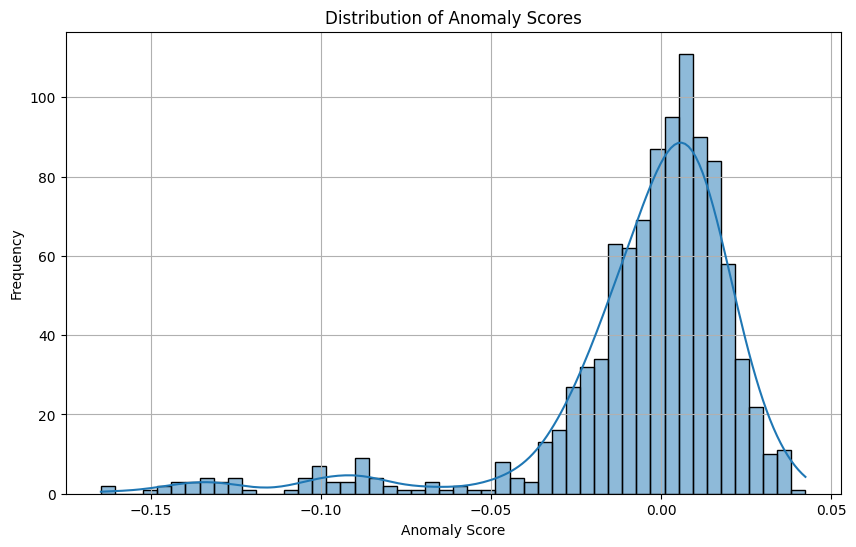

Number of anomalies detected (score < -0.03): 100
Percentage of anomalies: 10.00%


In [241]:
anomaly_scores = trained_pipeline.decision_function(features_df)

plt.figure(figsize=(10, 6))
sns.histplot(anomaly_scores, bins=50, kde=True)
plt.title('Distribution of Anomaly Scores')
plt.xlabel('Anomaly Score')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# You can also define a threshold and see how many are considered anomalies
# For Isolation Forest, scores are typically <= 0 for anomalies, with more negative being more anomalous.
# A common threshold is 0, but this depends on the 'contamination' parameter and desired sensitivity.
threshold = -0.03 # Example threshold
anomalies = anomaly_scores[anomaly_scores < threshold]
print(f"Number of anomalies detected (score < {threshold}): {len(anomalies)}")
print(f"Percentage of anomalies: {len(anomalies) / len(anomaly_scores) * 100:.2f}%")


In [207]:
results_df = features_df.copy()
results_df['anomaly_score'] = anomaly_scores
# Predict anomalies using the trained pipeline
predictions = trained_pipeline.predict(features_df)
results_df['is_anomaly'] = predictions
results_df['is_anomaly'] = results_df['is_anomaly'].map({1: False, -1: True}) # Map to boolean



In [242]:
def prepare_features_for_prediction(current_request_dict):
    """
    Prepares a feature DataFrame for a single incoming request,
    matching the V2 feature engineering.
    """
    print("Preparing features for current request (V2 logic)...")
    df = pd.DataFrame([current_request_dict])
    df['access_request_time'] = pd.to_datetime(df['access_request_time'])

    # Handle potential missing values (MUST match training V2)
    df['location'] = df['location'].fillna('Unknown/Unknown')
    df['device_OS'] = df['device_OS'].fillna('Unknown')
    df['device_type'] = df['device_type'].fillna('Unknown')
    df['resource_requested'] = df['resource_requested'].fillna('Unknown')

    # --- Replicate Feature Engineering (V2) ---
    # 1. Basic Temporal Features
    df['hour'] = df['access_request_time'].dt.hour
    df['day_of_week'] = df['access_request_time'].dt.dayofweek # Monday=0, Sunday=6
    df['time_only'] = df['access_request_time'].dt.time

    # 2. Cyclical Encoding
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    df['day_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
    df['day_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

    # 3. New Time Boundary Features (Booleans/Ints)
    # Assumes NIGHT_START_TIME and NIGHT_END_TIME are globally defined from policy config cell
    df['weekend_access'] = df['day_of_week'].apply(lambda d: 1 if d >= 5 else 0) # 1 if Sat/Sun

    current_time_obj = df['time_only'].iloc[0]
    if NIGHT_START_TIME <= NIGHT_END_TIME: # Normal case (e.g., 00:00-06:00)
        df['is_after_hours'] = 1 if NIGHT_START_TIME <= current_time_obj < NIGHT_END_TIME else 0
    else: # Midnight crossing case (e.g., 22:00-06:00)
        df['is_after_hours'] = 1 if current_time_obj >= NIGHT_START_TIME or current_time_obj < NIGHT_END_TIME else 0

    df['weekday_access_after_hours'] = ((df['weekend_access'] == 0) & (df['is_after_hours'] == 1)).astype(int)
    df['weekday_access_normal_time'] = ((df['weekend_access'] == 0) & (df['is_after_hours'] == 0)).astype(int)


    # --- Load historical data for lookups ---
    historical_df = load_historical_access_requests() # Uses the cached loader
    if historical_df.empty:
        print("Warning: Cannot calculate historical/frequency features due to missing historical data.")
        df['time_since_last_req_sec'] = 0
        df['requests_last_1h'] = 0
        df['requests_last_24h'] = 0
        df['resource_freq_last_24h'] = 0
    else:
        user_id = df['user_id'].iloc[0]
        current_time_dt = df['access_request_time'].iloc[0]
        current_resource = df['resource_requested'].iloc[0]

        # Filter historical data for the specific user AND time *before* current request
        user_history = historical_df[(historical_df['user_id'] == user_id) &
                                     (historical_df['access_request_time'] < current_time_dt)].copy() # Explicit copy
        print(f"Found {len(user_history)} historical requests for user {user_id} before current time {current_time_dt}.")

        # 4. Time Since Last Request
        if not user_history.empty:
            # Ensure user_history is sorted by time to get the correct last request
            user_history.sort_values(by='access_request_time', inplace=True)
            last_req_time = user_history['access_request_time'].iloc[-1]
            time_diff = current_time_dt - last_req_time
            df['time_since_last_req_sec'] = time_diff.total_seconds()
        else:
            df['time_since_last_req_sec'] = 0 # First request for user in historical data or no history

        # 6. Frequency Features (using user_history)
        one_hour_ago = current_time_dt - timedelta(hours=1)
        twenty_four_hours_ago = current_time_dt - timedelta(hours=24)

        # Count requests in the last hour (excluding current)
        reqs_1h = user_history[user_history['access_request_time'] >= one_hour_ago].shape[0]
        df['requests_last_1h'] = reqs_1h

        # Count requests in the last 24 hours (excluding current)
        reqs_24h = user_history[user_history['access_request_time'] >= twenty_four_hours_ago].shape[0]
        df['requests_last_24h'] = reqs_24h

        # Resource Access Frequency (User + Resource) - Last 24 hours
        resource_specific_history_24h = user_history[
            (user_history['resource_requested'] == current_resource) &
            (user_history['access_request_time'] >= twenty_four_hours_ago)
        ]
        df['resource_freq_last_24h'] = resource_specific_history_24h.shape[0]

    # 5. Contextual Features
    df['country'] = df['location'].apply(lambda x: x.split('/')[-1] if isinstance(x, str) and '/' in x else 'Unknown')

    # --- Define Final Feature Lists (MUST MATCH TRAINING V2) ---
    numerical_features = [
        'hour_sin', 'hour_cos', 'day_sin', 'day_cos',             # Cyclical Time
        'time_since_last_req_sec',                                # Time Delta
        'requests_last_1h', 'requests_last_24h',                  # Overall Freq
        'resource_freq_last_24h'                                  # Resource Freq
    ]
    categorical_features = [
        'resource_requested', 'country', 'device_OS', 'device_type', # Context
        'weekend_access', 'weekday_access_normal_time', 'weekday_access_after_hours' # Time Categories
    ]
    feature_columns = numerical_features + categorical_features

    # Ensure all expected columns exist, fill missing with appropriate defaults
    for col in feature_columns:
        if col not in df.columns:
            print(f"Warning: Feature '{col}' missing in input for prediction, adding default value.")
            if col in numerical_features:
                df[col] = 0.0 # Default for numerical
            elif col in ['weekend_access', 'weekday_access_normal_time', 'weekday_access_after_hours']:
                df[col] = 0 # Default for these specific categorical (binary)
            else:
                df[col] = 'Unknown' # Default for other categorical

    df_final = df[feature_columns].copy() # Select and order columns
    print("Feature preparation for prediction (V2) complete.")
    print("Prepared features:\n", df_final.head())
    return df_final